In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, classification_report, confusion_matrix)
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv("data_set/dating_app_behavior_encoded.csv")
df.shape

(50000, 80)

In [4]:
df = df.drop("interest_tags", axis=1)

In [30]:
corr_matrix = df.corr(numeric_only=True)

target_corr = corr_matrix['match_outcomes']

selected_features = target_corr[
    abs(target_corr) > 0.005
].index

print(selected_features)

Index(['mutual_matches', 'emoji_usage_rate', 'last_active_hour', 'height_cm',
       'weight_kg', 'match_outcomes', 'gender_Genderfluid',
       'sexual_orientation_Bisexual', 'sexual_orientation_Gay',
       'sexual_orientation_Lesbian', 'sexual_orientation_Pansexual',
       'sexual_orientation_Straight', 'location_type_Remote Area',
       'location_type_Suburban', 'income_bracket_Lower-Middle',
       'education_level_Postdoc', 'app_usage_time_label_Low',
       'swipe_time_of_day_Evening', 'swipe_time_of_day_Late Night',
       'swipe_time_of_day_Morning', 'zodiac_sign_Capricorn', 'zodiac_sign_Leo',
       'zodiac_sign_Sagittarius', 'body_type_Muscular',
       'relationship_intent_Networking'],
      dtype='str')


In [32]:
X = df[selected_features]
y = df['match_outcomes']

In [33]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, stratify=y)

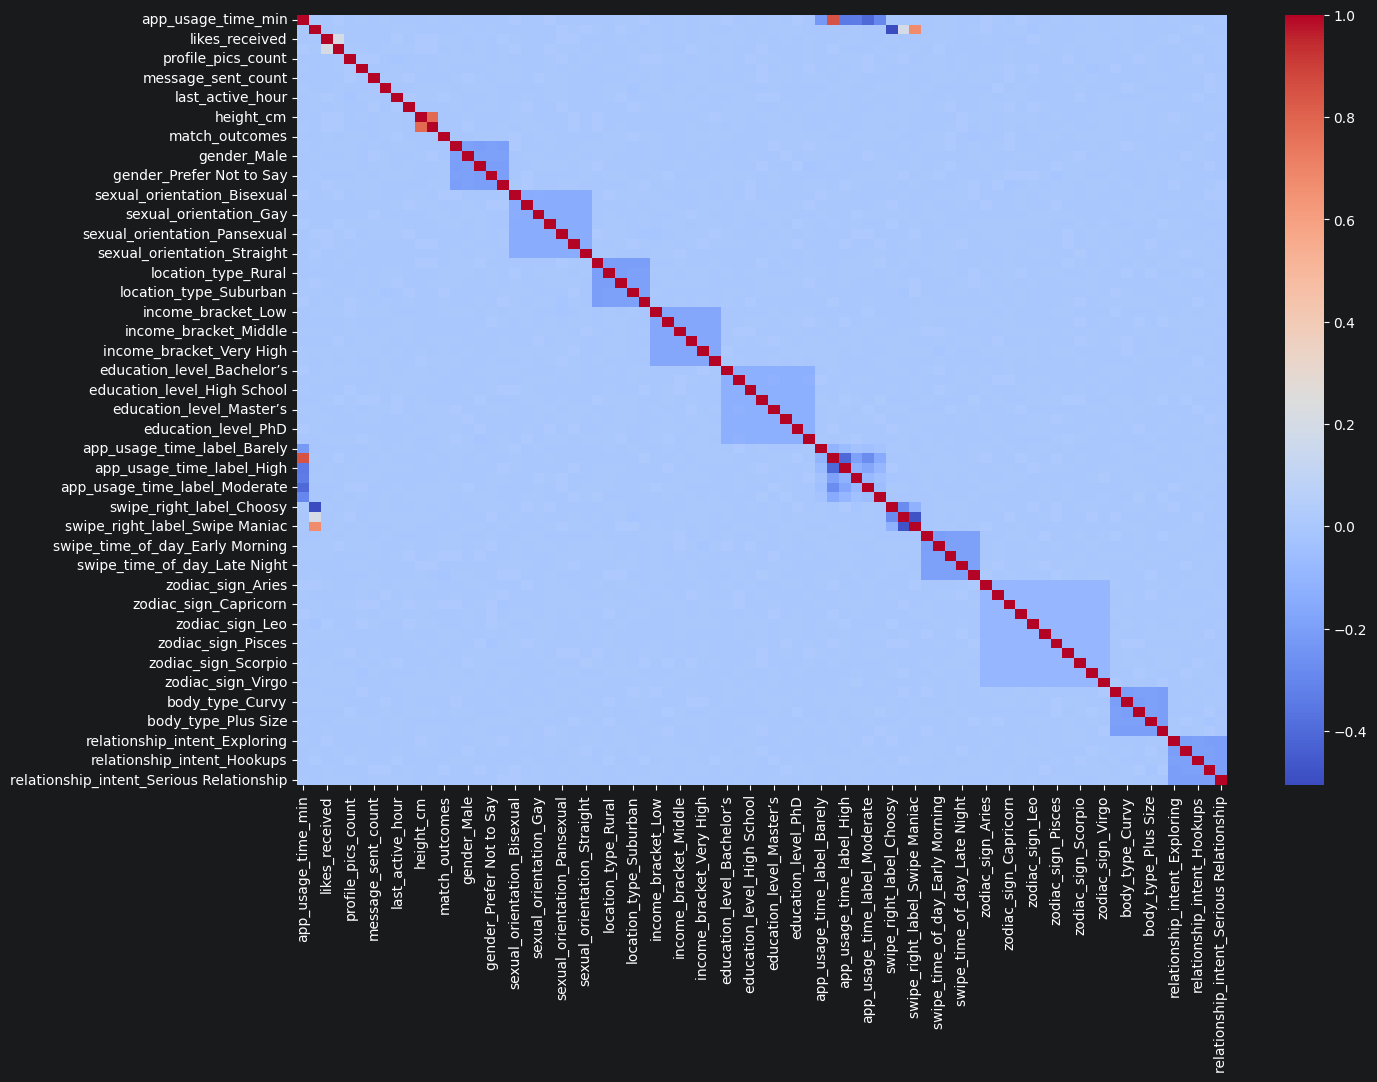

In [23]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(15,10))
sns.heatmap(corr, cmap="coolwarm")
plt.show()

In [24]:
df

,app_usage_time_min,swipe_right_ratio,likes_received,mutual_matches,profile_pics_count,bio_length,message_sent_count,emoji_usage_rate,last_active_hour,age,...,body_type_Average,body_type_Curvy,body_type_Muscular,body_type_Plus Size,body_type_Slim,relationship_intent_Exploring,relationship_intent_Friends Only,relationship_intent_Hookups,relationship_intent_Networking,relationship_intent_Serious Relationship
0,52,0.60,173,23,4,44,75,0.36,13,56,...,0,1,0,0,0,0,1,0,0,0
1,279,0.56,107,7,3,301,35,0.42,0,40,...,0,0,0,1,0,0,0,1,0,0
2,49,0.41,91,27,2,309,33,0.41,1,30,...,0,1,0,0,0,0,0,0,0,1
3,185,0.32,147,6,5,35,5,0.07,21,57,...,0,0,0,0,1,1,0,0,0,0
4,83,0.32,94,11,1,343,34,0.11,22,24,...,0,0,0,0,1,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
49995,130,0.69,99,8,5,235,9,0.19,15,45,...,0,0,0,1,0,0,0,0,0,0
49996,277,0.43,173,1,1,278,69,0.23,2,26,...,0,0,0,0,0,0,1,0,0,0
49997,73,0.50,123,8,1,128,94,0.36,5,45,...,0,0,0,0,0,0,0,0,0,1
49998,100,0.34,149,19,3,206,53,0.36,16,29,...,0,0,0,0,0,0,1,0,0,0


In [34]:
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.transform(x_test)

In [35]:
svm_model = SVC(C=1, gamma='scale', kernel="rbf")

In [36]:
svm_model.fit(x_train_scaled, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'rbf'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [37]:
y_pred = svm_model.predict(x_test_scaled)

In [39]:
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy: ", accuracy)

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:\n")
print(confusion_matrix(y_test, y_pred))

Accuracy:  0.095

Classification Report:

              precision    recall  f1-score   support

           0       0.09      0.10      0.09      1010
           1       0.10      0.10      0.10      1005
           2       0.10      0.11      0.11      1004
           3       0.10      0.08      0.09       984
           4       0.10      0.08      0.09       992
           5       0.09      0.10      0.09      1016
           6       0.11      0.11      0.11       998
           7       0.09      0.08      0.09       997
           8       0.09      0.10      0.10      1022
           9       0.09      0.07      0.08       972

    accuracy                           0.10     10000
   macro avg       0.10      0.09      0.09     10000
weighted avg       0.10      0.10      0.09     10000


Confusion Matrix:

[[105 101 112  97  92 107  94 101 118  83]
 [137 104 106  75  86 102  97  75 132  91]
 [130 106 113  89  79 109  95  89 114  80]
 [120 115  93  82  82 107 115  85 108  77]
 [132 1